In [1]:
import sys
!{sys.executable} -m pip install pandas
import pandas as pd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install numpy
import numpy as np


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Датасет

Датасет [Codon usage](https://archive.ics.uci.edu/dataset/577/codon+usage) представляет собой задачу биологической кластеризации, где истинные метки соответствуют таксономическим группам организмов. Это позволяет объективно оценить качество алгоритмов с использованием внешних метрик.

In [6]:
import pandas as pd

df = pd.read_csv("codon_usage.csv", low_memory=False)

In [7]:

df.head()

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


### EDA

In [8]:
df.shape

(13028, 69)

В результате изучения данных были выявлены несколько некорректно заполненных строк (название вида попало в столбец UUU), так что информацию об этих объектах необходимо удалить

In [9]:
# df.loc[5063]
# df.loc[486]

In [10]:
df = df.drop(index=[486, 5063])

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 13026 entries, 0 to 13027
Data columns (total 69 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Kingdom      13026 non-null  str    
 1   DNAtype      13026 non-null  int64  
 2   SpeciesID    13026 non-null  int64  
 3   Ncodons      13026 non-null  int64  
 4   SpeciesName  13026 non-null  str    
 5   UUU          13026 non-null  str    
 6   UUC          13026 non-null  str    
 7   UUA          13026 non-null  float64
 8   UUG          13026 non-null  float64
 9   CUU          13026 non-null  float64
 10  CUC          13026 non-null  float64
 11  CUA          13026 non-null  float64
 12  CUG          13026 non-null  float64
 13  AUU          13026 non-null  float64
 14  AUC          13026 non-null  float64
 15  AUA          13026 non-null  float64
 16  AUG          13026 non-null  float64
 17  GUU          13026 non-null  float64
 18  GUC          13026 non-null  float64
 19  GUA          13026 n

Датасет содержит 581012 объектов и 69 признаков. Удалим неинформативные:

In [12]:
y_true = df["Kingdom"]
df = df.drop(columns=["Kingdom", "SpeciesID", "SpeciesName"])
df.head()

,DNAtype,Ncodons,UUU,UUC,UUA,UUG,CUU,CUC,CUA,CUG,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,0,1995,0.01654,0.01203,0.00050,0.00351,0.01203,0.03208,0.00100,0.04010,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,0,1474,0.02714,0.01357,0.00068,0.00678,0.00407,0.02849,0.00204,0.04410,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,0,4862,0.01974,0.0218,0.01357,0.01543,0.00782,0.01111,0.01028,0.01193,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,0,1915,0.01775,0.02245,0.01619,0.00992,0.01567,0.01358,0.00940,0.01723,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,0,22831,0.02816,0.01371,0.00767,0.03679,0.01380,0.00548,0.00473,0.02076,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


Остались только числовые признаки.

In [13]:
df.describe()

,DNAtype,Ncodons,UUA,UUG,CUU,CUC,CUA,CUG,AUU,AUC,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
count,13026.000000,1.302600e+04,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,...,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000,13026.000000
mean,0.367265,7.961776e+04,0.020637,0.014104,0.017821,0.018287,0.019045,0.018452,0.028355,0.025038,...,0.005453,0.009930,0.006423,0.024181,0.021164,0.028291,0.021683,0.001640,0.000590,0.006179
std,0.688764,7.197556e+05,0.020710,0.009280,0.010587,0.014573,0.024252,0.016578,0.017507,0.014596,...,0.006601,0.008574,0.006388,0.013826,0.013039,0.014343,0.015019,0.001785,0.000882,0.010345
min,0.000000,1.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.602000e+03,0.005610,0.007103,0.010890,0.007830,0.005302,0.007180,0.016370,0.015130,...,0.001220,0.001690,0.001170,0.012390,0.011860,0.017360,0.009710,0.000560,0.000000,0.000410
50%,0.000000,2.929000e+03,0.015260,0.013360,0.016130,0.014560,0.009680,0.012800,0.025480,0.021540,...,0.003530,0.009270,0.004545,0.025425,0.019070,0.026085,0.020540,0.001380,0.000420,0.001130
75%,1.000000,9.120000e+03,0.029495,0.019808,0.022730,0.025110,0.017255,0.024325,0.038117,0.031860,...,0.007150,0.015928,0.010250,0.034190,0.027690,0.036800,0.031128,0.002370,0.000830,0.002890
max,12.000000,4.066258e+07,0.151330,0.101190,0.089780,0.100350,0.163920,0.107370,0.154060,0.088600,...,0.055540,0.098830,0.058430,0.185660,0.113840,0.144890,0.158550,0.045200,0.025610,0.106700


В ходе анализа статистик признаков было выявлено, что признаки имеют различные масштабы значений. Наблюдается значительный разброс между минимальными и максимальными значениями. Необходимо нормализовать данные перед применением алгоритмов кластеризации.

#### Обработка пропущенных значений

In [14]:
df.isnull().sum()

DNAtype    0
Ncodons    0
UUU        0
UUC        0
UUA        0
          ..
GAA        0
GAG        0
UAA        0
UAG        0
UGA        0
Length: 66, dtype: int64

Пропущенных значений нет, информация полная.

#### Анализ распределений

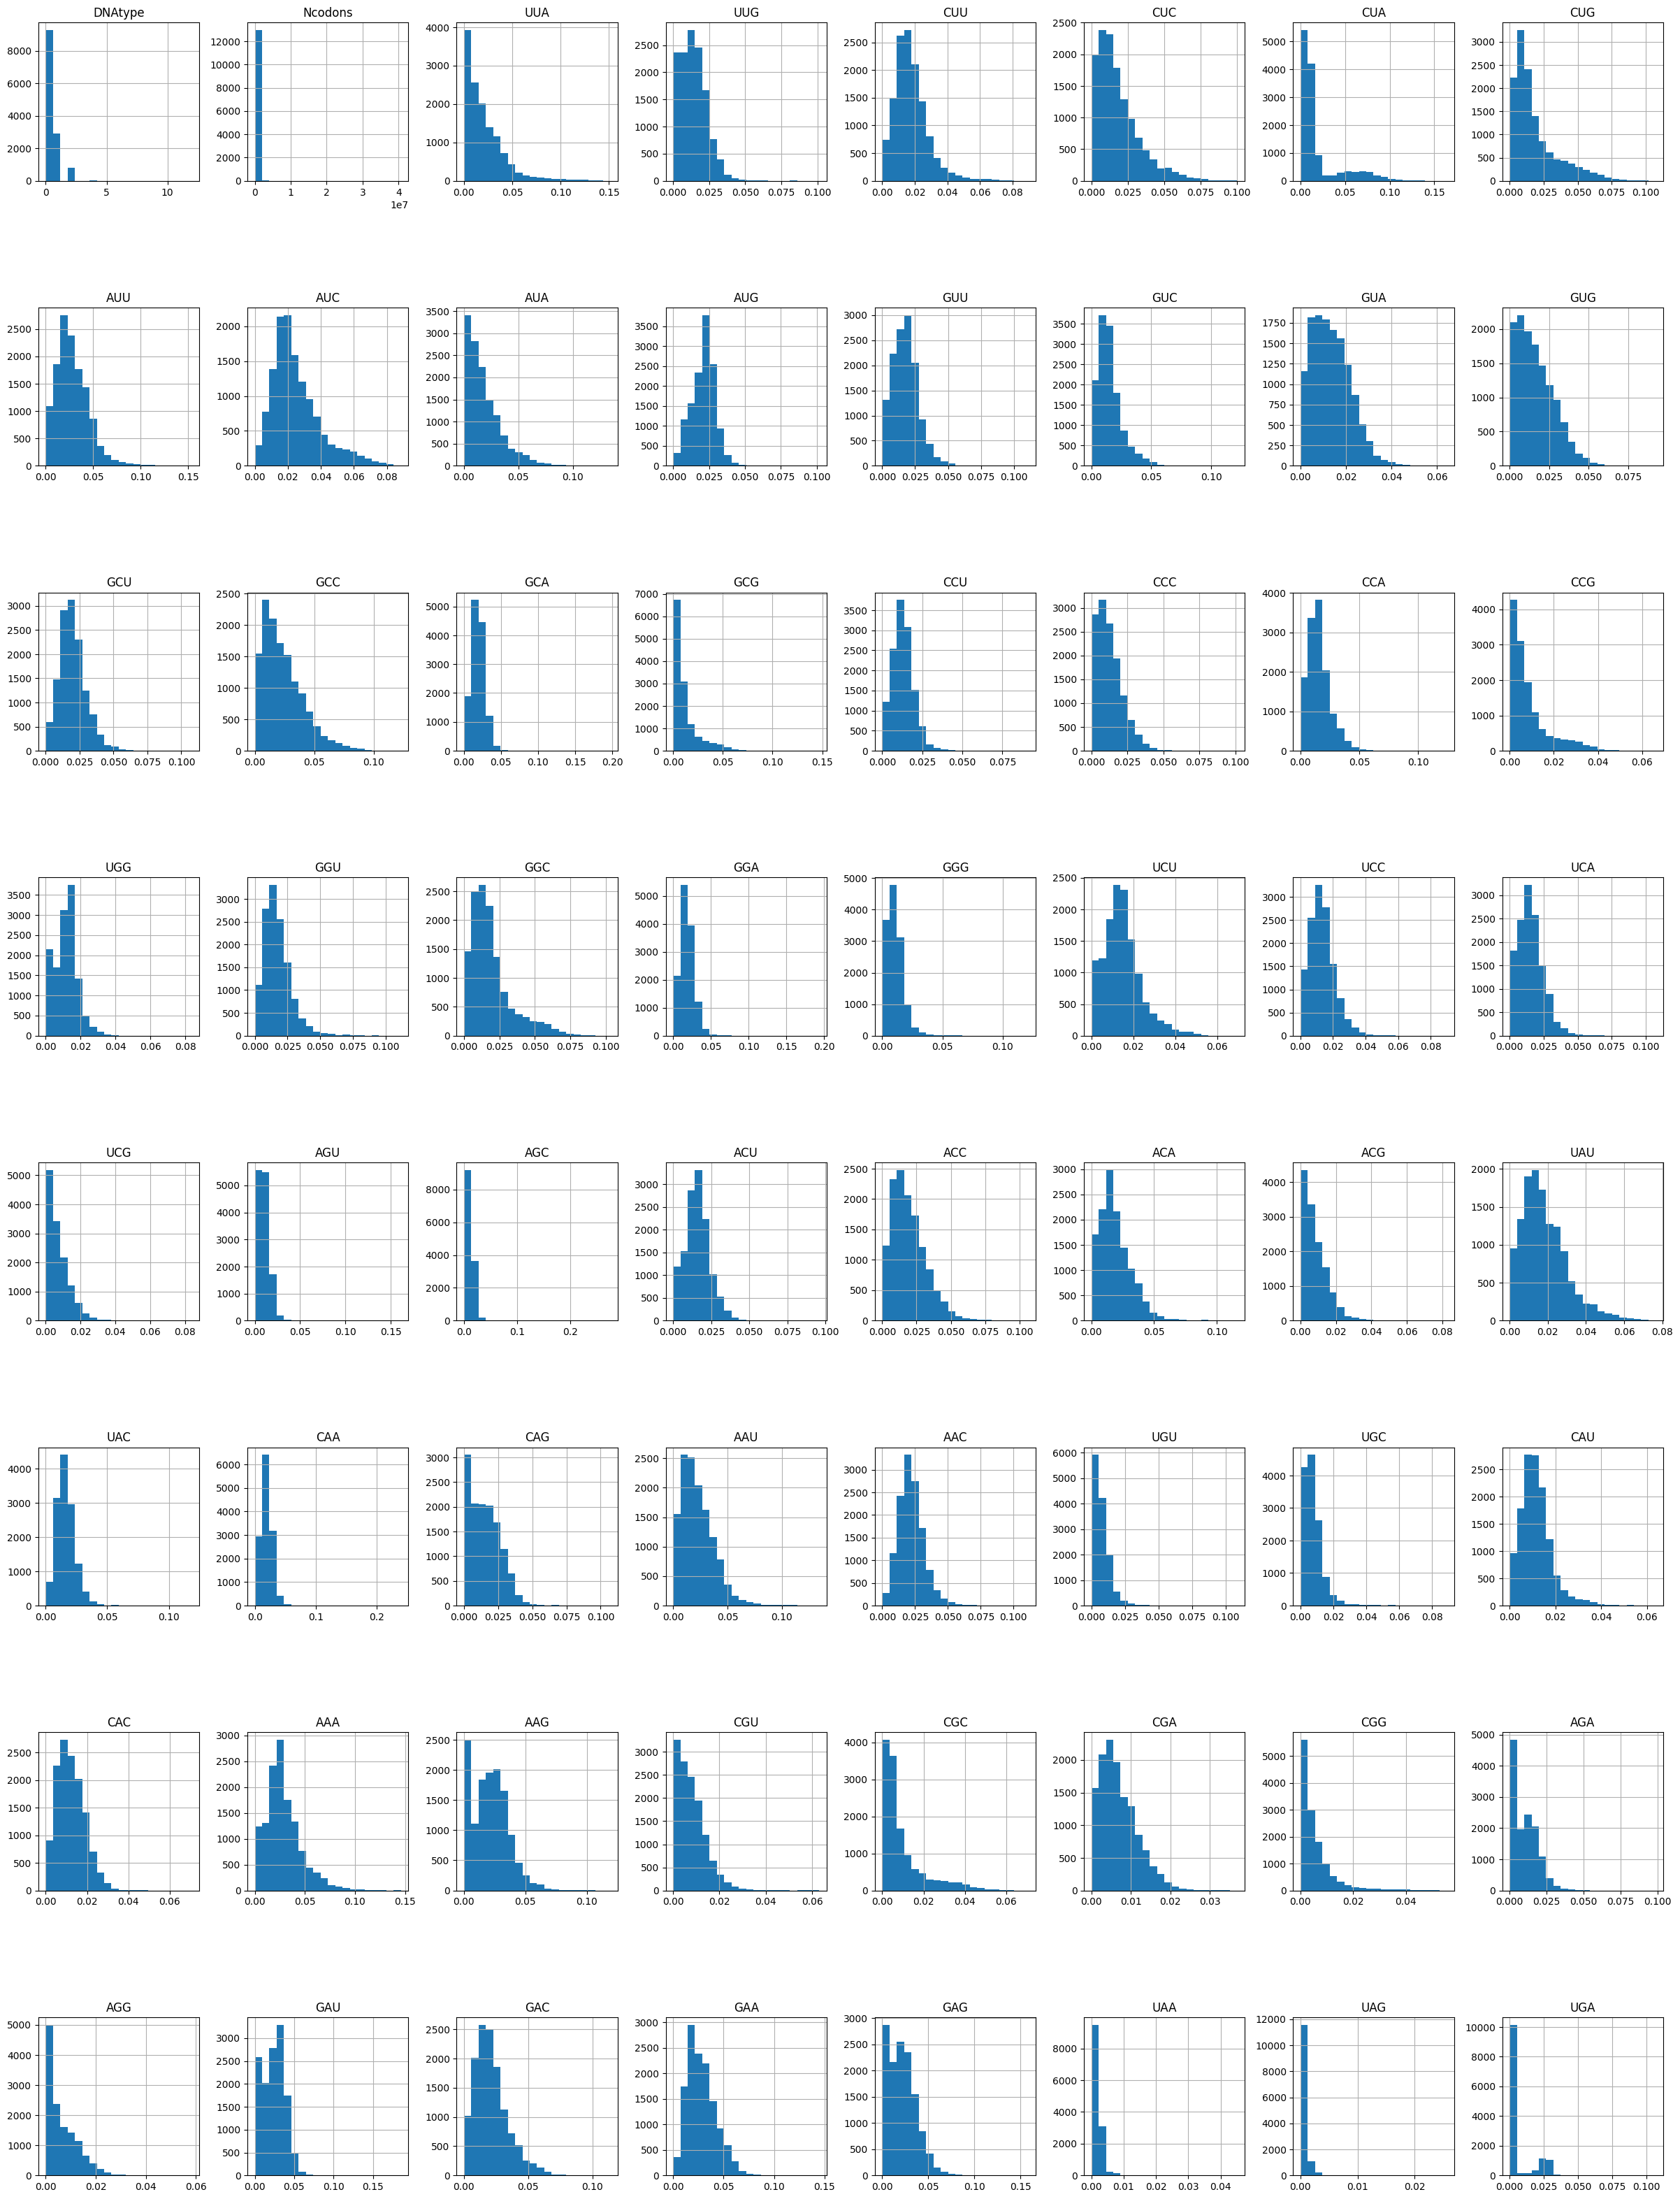

In [15]:
df.hist(figsize=(30, 40), bins=20)

plt.subplots_adjust(hspace=0.8)
plt.show()

Анализ гистограмм показал, что превалирует нормальное распределение данных.


#### Корреляция

Помогает оценить связи между признаками:\
+1 → сильная положительная связь\
-1 → сильная отрицательная\
&nbsp;0 → связи нет

Тепловая карта для наглядности

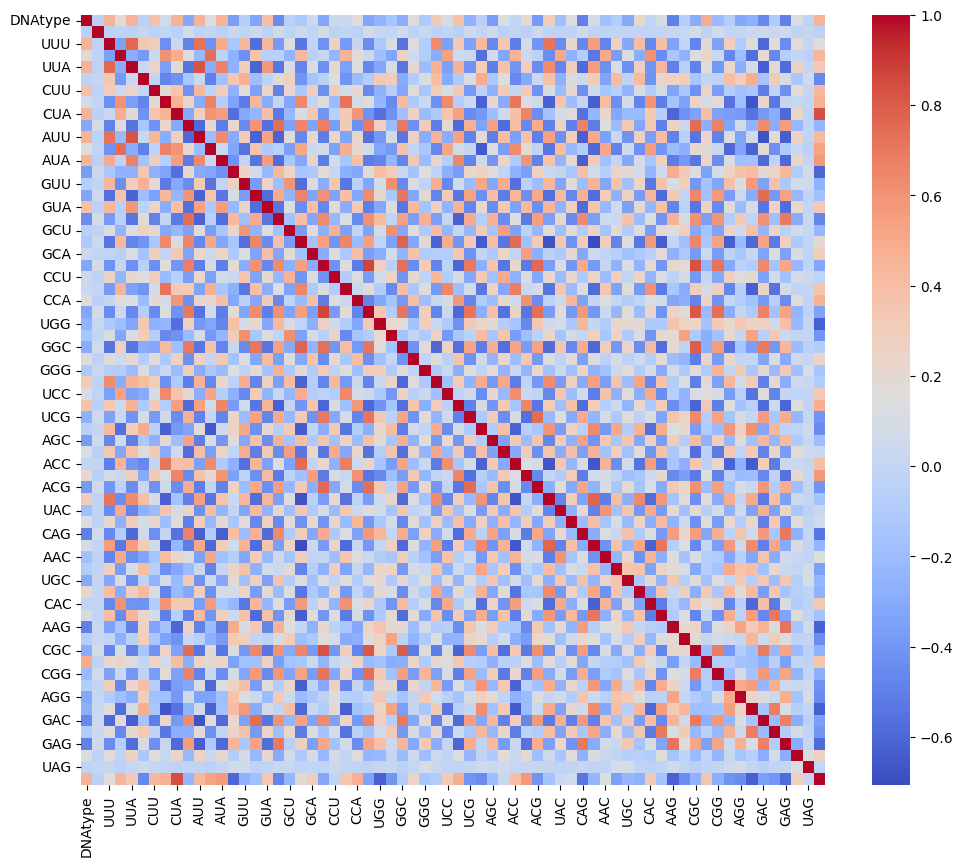

In [16]:
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [17]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)
print(high_corr_pairs[high_corr_pairs > 0.9])

Series([], dtype: float64)


Анализ корреляционной матрицы показал отсутствие признаков с высокой линейной зависимостью (коэффициент корреляции > 0.9). 
Это свидетельствует о том, что признаки содержат различную информацию и не являются избыточными.

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df)

Для корректной работы алгоритмов кластеризации была выполнена нормализация признаков с использованием StandardScaler. 
Это позволило привести все признаки к единому масштабу.

### Алгоритм кластеризации K-means

Изначально в датасете указано 7 типов лесистости. Не будем ипользовать эту информацию при обучении, только при сравнении работы различных алгоритмов кластеризации.

In [19]:
class MyKMeans:
    def __init__(self, n_clusters=2, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def _init_centroids_kmeans_pp(self, X):
        np.random.seed(self.random_state)
    
        n_samples = X.shape[0]
        centroids = []
    
        # первый центр — случайный
        idx = np.random.randint(n_samples)
        centroids.append(X[idx])
    
        # остальные центры - с вероятностью, пропорциональной расстоянию до ближайшего уже выбранного центра
        for _ in range(1, self.n_clusters):
            distances = np.array([
                min(np.linalg.norm(x - c)**2 for c in centroids)
                for x in X
            ])
    
            probs = distances / distances.sum()
            idx = np.random.choice(n_samples, p=probs)
            centroids.append(X[idx])
    
        return np.array(centroids)

    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        np.random.seed(self.random_state)

        # инициализация центроидов через k-means++
        self.centroids = self._init_centroids_kmeans_pp(X)
        # self.centroids = X[np.random.choice(X.shape[0], self.n_clusters, replace=False)]

        for i in range(self.max_iter):
            # считаем расстояния до центров
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            # назначаем кластеры
            labels = np.argmin(distances, axis=1)

            # пересчитываем центры
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # проверка сходимости
            shift = np.linalg.norm(self.centroids - new_centroids)

            self.centroids = new_centroids

            if shift < self.tol:
                break

        self.labels_ = labels
        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

### Обучение моделей кластеризации. Подбор гиперпараметров

#### Найдем оптимальное количество кластеров для MyKMeans

Посчитаем silhouette score

In [20]:
from sklearn.metrics import silhouette_score

scores = []

k_values = range(2, 15)

for k in k_values:
    model = MyKMeans(n_clusters=k, random_state=42)
    model.fit(X)

    score = silhouette_score(X, model.labels_, metric="euclidean", sample_size=10000)
    print(
        "Для n_clusters =",
        k,
        "silhouette score :",
        score,
    )
    scores.append(score)

best_k = k_values[np.argmax(scores)]
print("Лучшее k:", best_k)

Для n_clusters = 2 silhouette score : 0.17895861357485995
Для n_clusters = 3 silhouette score : 0.24844618168056787
Для n_clusters = 4 silhouette score : 0.20080774267899493
Для n_clusters = 5 silhouette score : 0.18324775648591657
Для n_clusters = 6 silhouette score : 0.16292414615945636
Для n_clusters = 7 silhouette score : 0.16346014107083606
Для n_clusters = 8 silhouette score : 0.15851253241846489
Для n_clusters = 9 silhouette score : 0.1437821658110866
Для n_clusters = 10 silhouette score : 0.1415759352224629
Для n_clusters = 11 silhouette score : 0.1408966822146409
Для n_clusters = 12 silhouette score : 0.1493564101927375
Для n_clusters = 13 silhouette score : 0.11807010683982612
Для n_clusters = 14 silhouette score : 0.11721596335807608
Лучшее k: 3


Таким образом, алгоритм лучше всего разделил данные на 3 кластера. Посмотрим на распределение кластеров

In [21]:
my_kmeans = MyKMeans(n_clusters=3)
my_kmeans.fit(X)
unique, counts = np.unique(my_kmeans.labels_, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(6858), np.int64(1): np.int64(2372), np.int64(2): np.int64(3796)}


Возьмем для обучения и дальнейшего сравнения метрик качества реализованный алгоритм кластеризации и k-means, DBSCAN из `scikit-learn`

Подберем количеств кластеров для KMeans

In [22]:
from sklearn.cluster import KMeans

scores = []

for k in k_values:
    model = KMeans(n_clusters=k, init = 'k-means++', random_state=42)
    model.fit(X)

    score = silhouette_score(X, model.labels_, metric="euclidean", sample_size=10000)
    print(
        "Для n_clusters =",
        k,
        "silhouette score :",
        score,
    )
    scores.append(score)

best_k = k_values[np.argmax(scores)]
print("Лучшее k:", best_k)

kmeans = KMeans(n_clusters=3, init = 'k-means++', random_state=42)

Для n_clusters = 2 silhouette score : 0.1936947983803666
Для n_clusters = 3 silhouette score : 0.24835677429196076
Для n_clusters = 4 silhouette score : 0.2007075403796843
Для n_clusters = 5 silhouette score : 0.1642695183269856
Для n_clusters = 6 silhouette score : 0.14841853834306198
Для n_clusters = 7 silhouette score : 0.12552205664958074
Для n_clusters = 8 silhouette score : 0.12152787028779767
Для n_clusters = 9 silhouette score : 0.12527525237357487
Для n_clusters = 10 silhouette score : 0.12303886479768462
Для n_clusters = 11 silhouette score : 0.13011930380572254
Для n_clusters = 12 silhouette score : 0.11521859811896513
Для n_clusters = 13 silhouette score : 0.11573773757476638
Для n_clusters = 14 silhouette score : 0.11340579990331544
Лучшее k: 3


Для алгоритма DBSCAN подберем eps и min_samples

In [23]:
from sklearn.cluster import DBSCAN

dbscan_results = []
for eps in [0.3, 0.5, 0.7]:
    for min_samples in [3, 5, 10, 20]:
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        model.fit(X)
        labels = model.labels_

        # проверка (DBSCAN может дать 1 кластер)
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
        else:
            score = -1

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "score": score
        })

In [24]:
import pandas as pd

df_db = pd.DataFrame(dbscan_results)
print(df_db)

best_dbscan_params = df_db.sort_values(by="score", ascending=False).iloc[0]

print(best_dbscan_params)

    eps  min_samples     score
0   0.3            3 -0.435797
1   0.3            5 -0.403635
2   0.3           10 -0.199667
3   0.3           20 -0.156929
4   0.5            3 -0.457606
5   0.5            5 -0.400949
6   0.5           10 -0.305485
7   0.5           20 -0.155538
8   0.7            3 -0.464082
9   0.7            5 -0.401051
10  0.7           10 -0.321435
11  0.7           20 -0.178507
eps             0.500000
min_samples    20.000000
score          -0.155538
Name: 7, dtype: float64


Для сравнения метрик качества выбираем eps = 0.5, min_samples = 20

Посмотрим, на сколько кластеров разделил данные DBSCAN с лучшими параметрами:

In [25]:
dbscan = DBSCAN(eps=0.5, min_samples=20, n_jobs=-1)
labels = dbscan.fit_predict(X)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(n_clusters)

3


Итого, все три реализации разделили данные лучшим образов на 3 кластера

### Сравнение качества моделей

In [26]:
import time
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

results = []

def evaluate_model(name, model, X, y_true):
    start = time.time()
    
    model.fit(X)
    labels = model.labels_
    
    end = time.time()
    
    results.append({
        "model": name,
        "time": end - start,
        "DBI": davies_bouldin_score(X, labels),
        "CH": calinski_harabasz_score(X, labels),
        "ARI": adjusted_rand_score(y_true, labels)
    })

Для оценки качества кластеризации использовались внешние метрики: Davies–Bouldin Index (DBI), Calinski–Harabasz Score (CH) и Adjusted Rand Index (ARI). Также измерялось время обучения моделей.
* DBI сравнивает расстояния внутри кластера и между кластерами (меньше = лучше)
* CH сравнивает межкластерную дисперсию (насколько кластеры далеко друг от друга) и внутрикластерную дисперсию (насколько они плотные) (больше = лучше)
* ARI показывает, насколько правильно объекты распределены по кластерам относительно истинной разметки, диапазон: [-1, 1]
  * ~ 1 → идеально совпадает
  * ~ 0 → случайно
  * < 0 → хуже случайного

In [27]:
evaluate_model("MyKMeans", MyKMeans(n_clusters=3), X, y_true)
evaluate_model("KMeans", kmeans, X, y_true)
evaluate_model("DBSCAN", dbscan, X, y_true)

In [28]:
df_final = pd.DataFrame(results)
print(df_final)

      model      time       DBI           CH       ARI
0  MyKMeans  0.201264  1.455813  3580.036888  0.165705
1    KMeans  0.014527  1.455779  3580.038125  0.165614
2    DBSCAN  0.189930  1.144643    25.247666 -0.001255


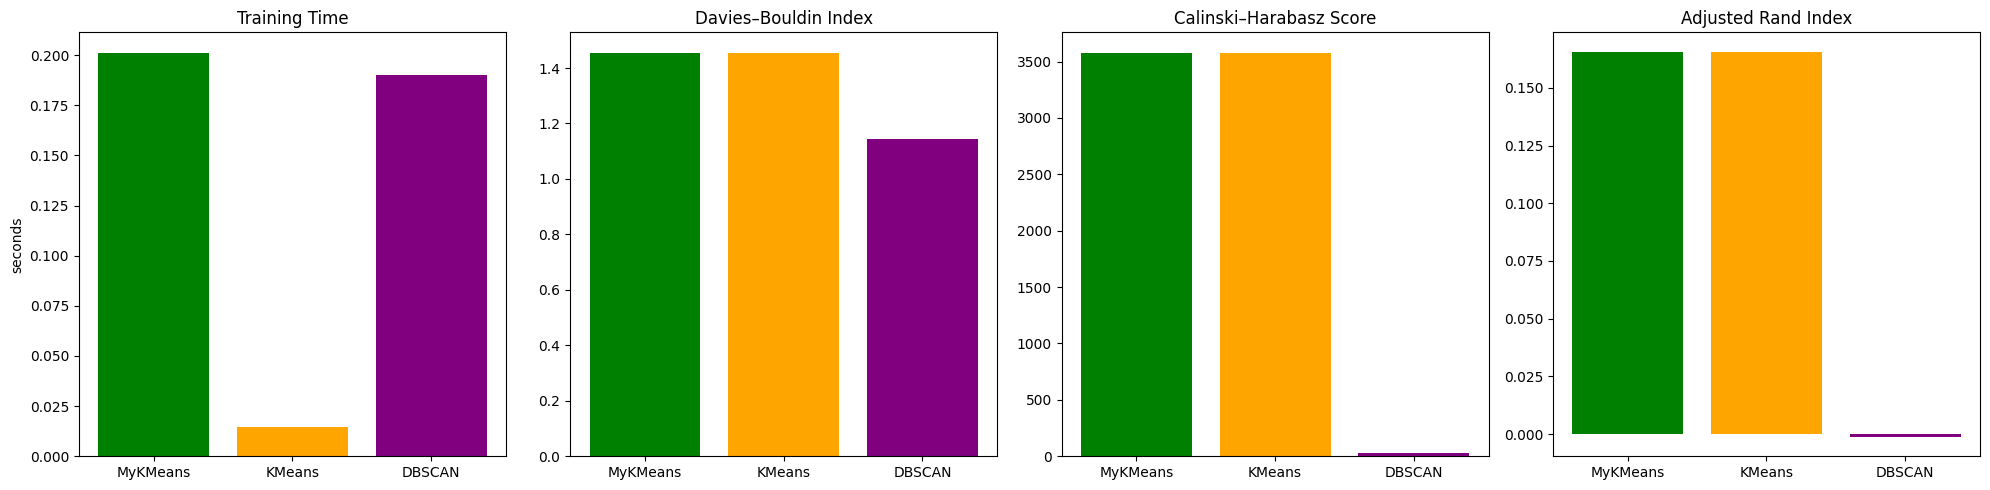

In [29]:
colors = ["green", "orange", "purple"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].bar(df_final["model"], df_final["time"], color=colors)
axes[0].set_title("Training Time")
axes[0].set_ylabel("seconds")

axes[1].bar(df_final["model"], df_final["DBI"], color=colors)
axes[1].set_title("Davies–Bouldin Index")

axes[2].bar(df_final["model"], df_final["CH"], color=colors)
axes[2].set_title("Calinski–Harabasz Score")

axes[3].bar(df_final["model"], df_final["ARI"], color=colors)
axes[3].set_title("Adjusted Rand Index")

plt.tight_layout() 
plt.show()

Можно заметить, что MyKMeans дает тот же результат, что и стандартный KMeans, только работает медленнее. 
Алгоритм DBSCAN показал противоречивые результаты: при относительно низком значении индекса Davies–Bouldin (что формально указывает на хорошее разделение кластеров), значения метрик Calinski–Harabasz и Adjusted Rand Index оказались крайне низкими. Это свидетельствует о том, что DBSCAN выделяет лишь небольшие плотные группы точек, игнорируя значительную часть данных как шум, что делает его менее пригодным для данного датасета.


### Снижение размерности с помощью PCA

Сначала посмотрим, как меняется дисперсия в зависимости от числа компонент

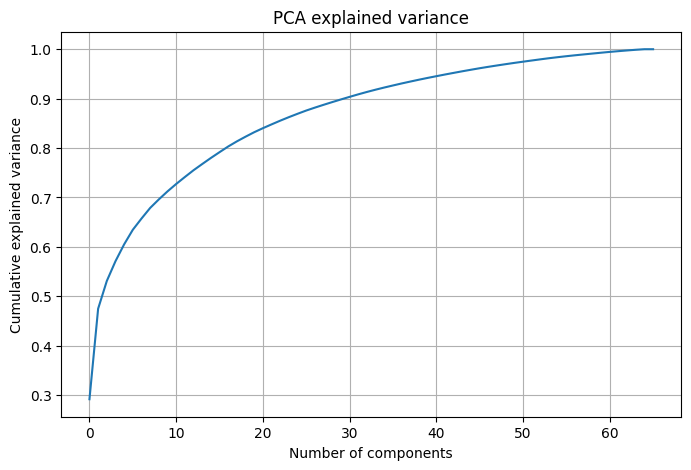

In [30]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid()
plt.show()

In [31]:
for threshold in [0.8, 0.9, 0.95]:
    n_comp = np.argmax(cum_var >= threshold) + 1
    print(f"{int(threshold*100)}% variance -> {n_comp} компонент")

80% variance -> 17 компонент
90% variance -> 31 компонент
95% variance -> 43 компонент


In [42]:
components_list = [2, 3, 5, 10, 17, 25, 31, 40, 43]

def evaluate(X, labels):
    # игнорируем случай, когда 1 кластер
    if len(set(labels)) <= 1:
        return None
    
    return {
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels)
    }

In [43]:
results = []

for n in components_list:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    
    labels_kmeans = kmeans.fit_predict(X_pca)
    
    my_kmeans = MyKMeans(n_clusters=3)
    my_kmeans.fit(X_pca)
    labels_my_kmeans = my_kmeans.labels_
    
    labels_db = dbscan.fit_predict(X_pca)
    results.append({
        "n_components": n,
        "kmeans": evaluate(X_pca, labels_kmeans),
        "my_kmeans": evaluate(X_pca, labels_my_kmeans),
        "dbscan": evaluate(X_pca, labels_db)
    })

In [44]:
for r in results:
    print(r)

{'n_components': 2, 'kmeans': {'silhouette': 0.5561353320053886, 'davies_bouldin': 0.5953808977572328, 'calinski_harabasz': 18888.73123674219}, 'my_kmeans': {'silhouette': 0.5562845601497839, 'davies_bouldin': 0.5952192614365431, 'calinski_harabasz': 18888.70889068419}, 'dbscan': {'silhouette': -0.24078725332621903, 'davies_bouldin': 20.493862739529952, 'calinski_harabasz': 7.9679478130066554}}
{'n_components': 3, 'kmeans': {'silhouette': 0.4881206493324193, 'davies_bouldin': 0.7399662903833127, 'calinski_harabasz': 12961.380990406838}, 'my_kmeans': {'silhouette': 0.4881206493324193, 'davies_bouldin': 0.7399662903833127, 'calinski_harabasz': 12961.380990406837}, 'dbscan': {'silhouette': -0.4616389209212583, 'davies_bouldin': 1.3767615692878061, 'calinski_harabasz': 196.37545578527326}}
{'n_components': 5, 'kmeans': {'silhouette': 0.4105830342027114, 'davies_bouldin': 0.9038658211022429, 'calinski_harabasz': 9148.561531875906}, 'my_kmeans': {'silhouette': 0.4105894159437804, 'davies_bou

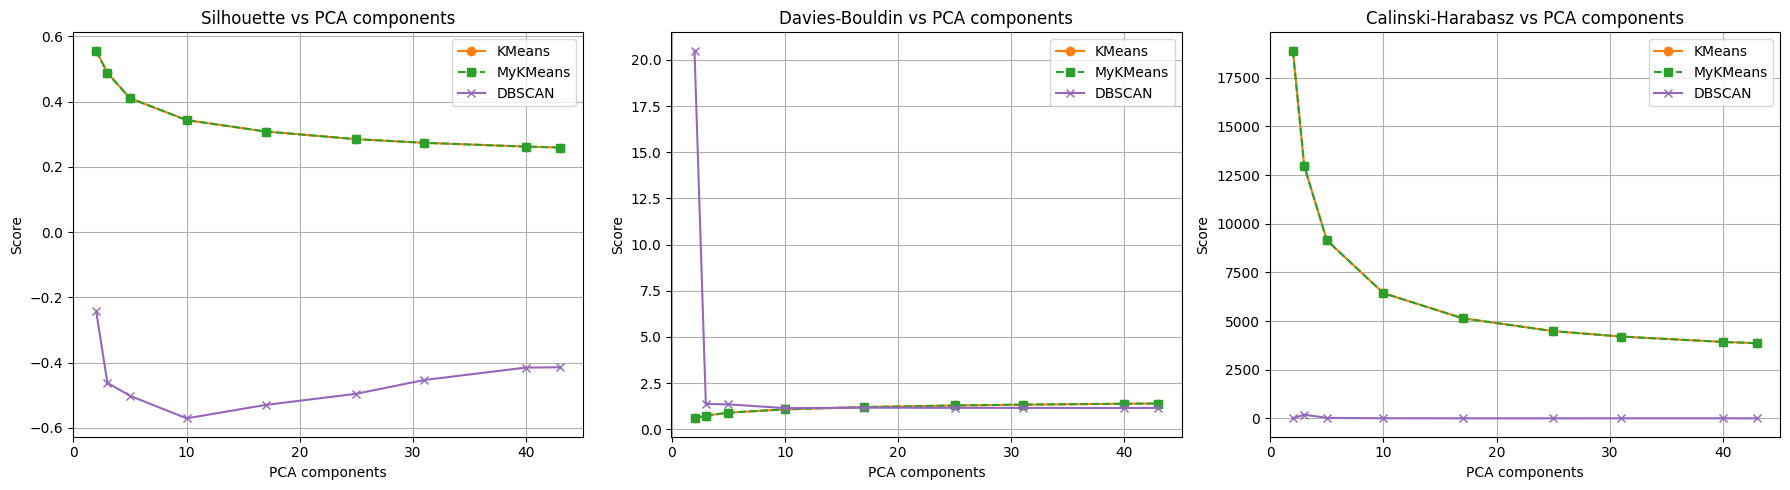

In [55]:
n_vals = [r["n_components"] for r in results]

metrics = {
    "Silhouette": {
        "KMeans": [r["kmeans"]["silhouette"] for r in results],
        "MyKMeans": [r["my_kmeans"]["silhouette"] for r in results],
        "DBSCAN": [r["dbscan"]["silhouette"] for r in results],
        "ylabel": "Score",
        "best": "max"
    },
    "Davies-Bouldin": {
        "KMeans": [r["kmeans"]["davies_bouldin"] for r in results],
        "MyKMeans": [r["my_kmeans"]["davies_bouldin"] for r in results],
        "DBSCAN": [r["dbscan"]["davies_bouldin"] for r in results],
        "ylabel": "Score",
        "best": "min"
    },
    "Calinski-Harabasz": {
        "KMeans": [r["kmeans"]["calinski_harabasz"] for r in results],
        "MyKMeans": [r["my_kmeans"]["calinski_harabasz"] for r in results],
        "DBSCAN": [r["dbscan"]["calinski_harabasz"] for r in results],
        "ylabel": "Score",
        "best": "max"
    }
}

colors = {"KMeans": "tab:orange", "MyKMeans": "tab:green", "DBSCAN": "tab:purple"}
markers = {"KMeans": "o", "MyKMeans": "s", "DBSCAN": "x"}
linestyles = {"KMeans": "-", "MyKMeans": "--", "DBSCAN": "-"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric_name, metric_data) in zip(axes, metrics.items()):
    for algo in ["KMeans", "MyKMeans", "DBSCAN"]:
        ax.plot(
            n_vals,
            metric_data[algo],
            label=algo,
            color=colors[algo],
            marker=markers[algo],
            linestyle=linestyles[algo]
        )
    ax.set_title(f"{metric_name} vs PCA components")
    ax.set_xlabel("PCA components")
    ax.set_ylabel(metric_data["ylabel"])
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

Наилучшее качество кластеризации методом KMeans достигается при использовании 2 главных компонент (silhouette ≈ 0.56).
При увеличении числа компонент наблюдается монотонное ухудшение качества кластеризации, что связано с ростом шума.
Реализация MyKMeans показала результаты, практически идентичные библиотечной реализации sklearn, что дополнительно подтверждает корректность ее работы.